# Exploratory Data Analysis (EDA)

This notebook contains the exploratory data analysis for the Bluestock Mutual Fund Capstone Project.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Create charts directory
os.makedirs('../reports/charts', exist_ok=True)
os.makedirs('charts', exist_ok=True)

# Load data
raw_dir = '../data/processed/'
df_nav = pd.read_csv(raw_dir + '02_nav_history.csv')
df_nav['date'] = pd.to_datetime(df_nav['date'])

df_fund = pd.read_csv(raw_dir + '01_fund_master.csv')
df_aum = pd.read_csv(raw_dir + '03_aum_by_fund_house.csv')
df_sip = pd.read_csv(raw_dir + '04_monthly_sip_inflows.csv')
df_cat = pd.read_csv(raw_dir + '05_category_inflows.csv')
df_folio = pd.read_csv(raw_dir + '06_industry_folio_count.csv')
df_perf = pd.read_csv(raw_dir + '07_scheme_performance.csv')
df_tx = pd.read_csv(raw_dir + '08_investor_transactions.csv')
df_port = pd.read_csv(raw_dir + '09_portfolio_holdings.csv')

import warnings
warnings.filterwarnings('ignore')


Matplotlib is building the font cache; this may take a moment.


In [2]:

# 1. NAV trend analysis
fig = px.line(df_nav, x='date', y='nav', color='amfi_code', title='Daily NAV for All Schemes (2022-2026)')
fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.1, annotation_text='2023 Bull Run')
fig.add_vrect(x0='2024-01-01', x1='2024-12-31', fillcolor='red', opacity=0.1, annotation_text='2024 Corrections')
fig.write_image('../reports/charts/nav_trend.png', engine='kaleido', width=1000, height=600)
fig.show()


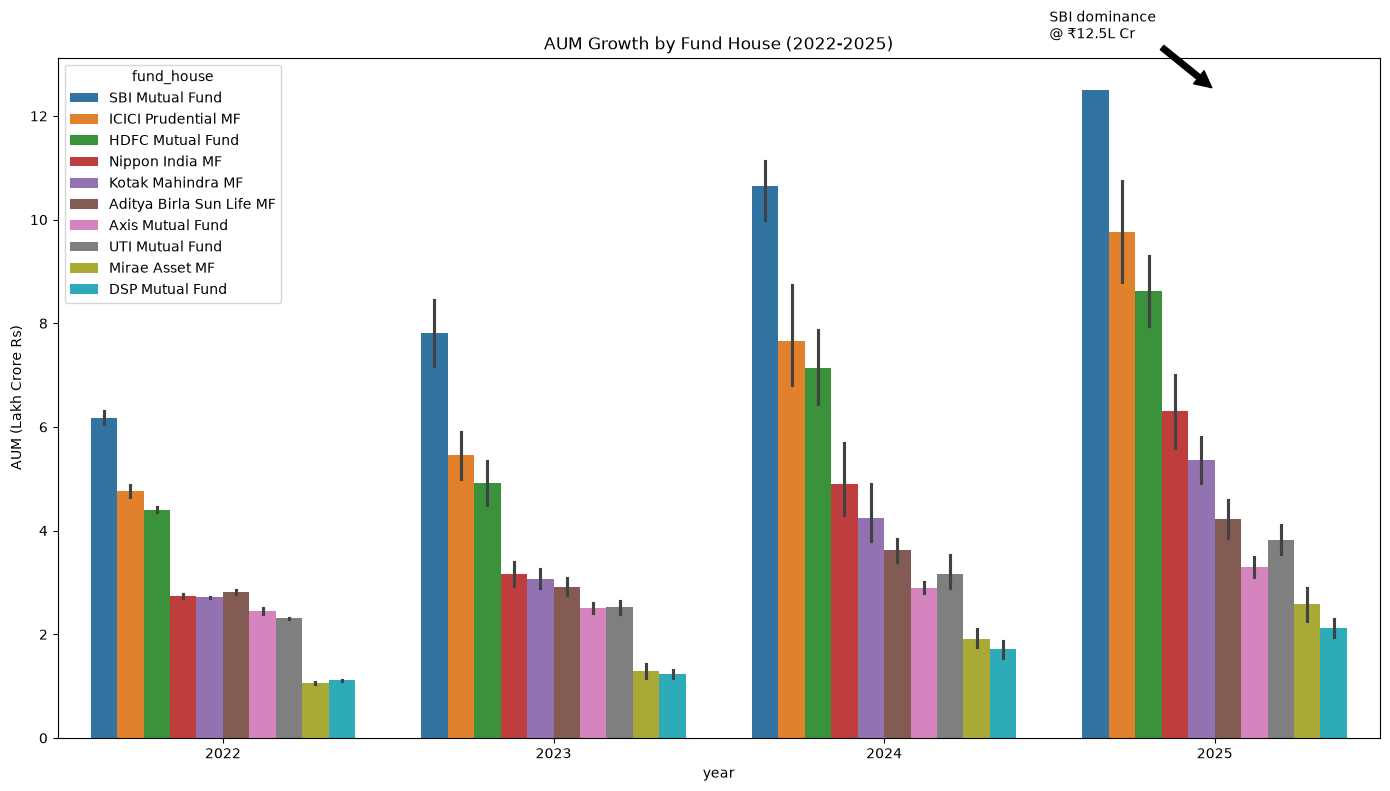

In [3]:

# 2. AUM growth bar chart
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year
# Get top fund houses by max AUM
top_houses = df_aum.groupby('fund_house')['aum_lakh_crore'].max().nlargest(10).index
df_aum_top = df_aum[df_aum['fund_house'].isin(top_houses)]

plt.figure(figsize=(14, 8))
sns.barplot(data=df_aum_top, x='year', y='aum_lakh_crore', hue='fund_house')
plt.title('AUM Growth by Fund House (2022-2025)')
plt.ylabel('AUM (Lakh Crore Rs)')
plt.annotate('SBI dominance\n@ ₹12.5L Cr', xy=(3, 12.5), xytext=(2.5, 13.5),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.tight_layout()
plt.savefig('../reports/charts/aum_growth.png')
plt.show()


In [4]:

# 3. SIP inflow time-series
fig = px.line(df_sip, x='month', y='sip_inflow_crore', title='Monthly SIP Inflow Trend (2022-2025)')
fig.add_annotation(x='2025-12', y=31002, text='All-time high: ₹31,002 Cr', showarrow=True, arrowhead=1)
fig.write_image('../reports/charts/sip_inflow.png', engine='kaleido', width=1000, height=600)
fig.show()


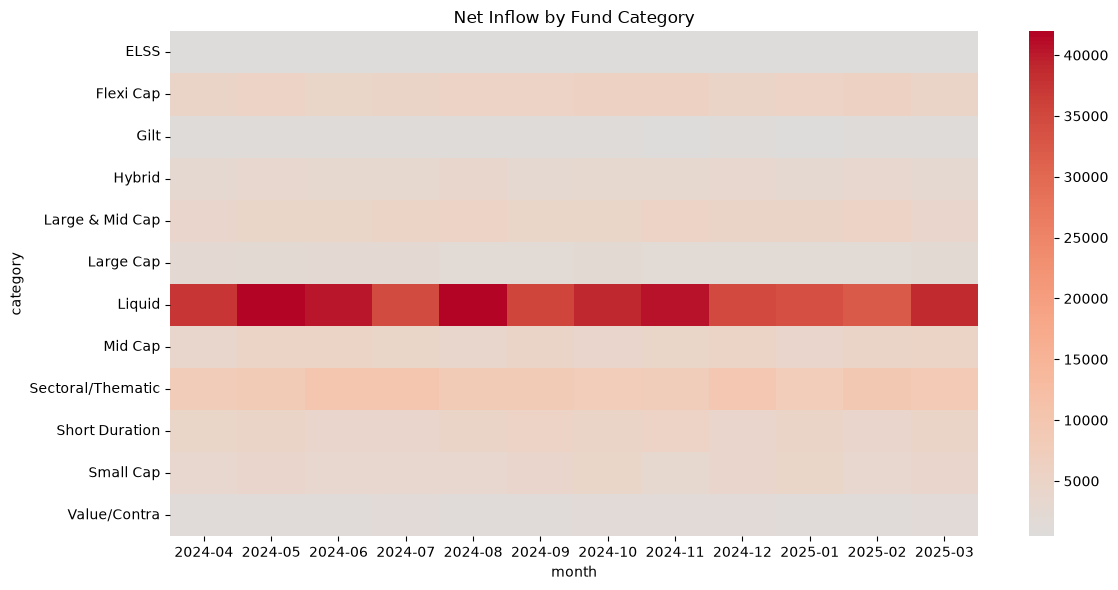

In [5]:

# 4. Category inflow heatmap
cat_pivot = df_cat.pivot(index='category', columns='month', values='net_inflow_crore').fillna(0)
plt.figure(figsize=(12, 6))
sns.heatmap(cat_pivot, cmap='coolwarm', center=0, annot=False)
plt.title('Net Inflow by Fund Category')
plt.tight_layout()
plt.savefig('../reports/charts/category_inflow_heatmap.png')
plt.show()


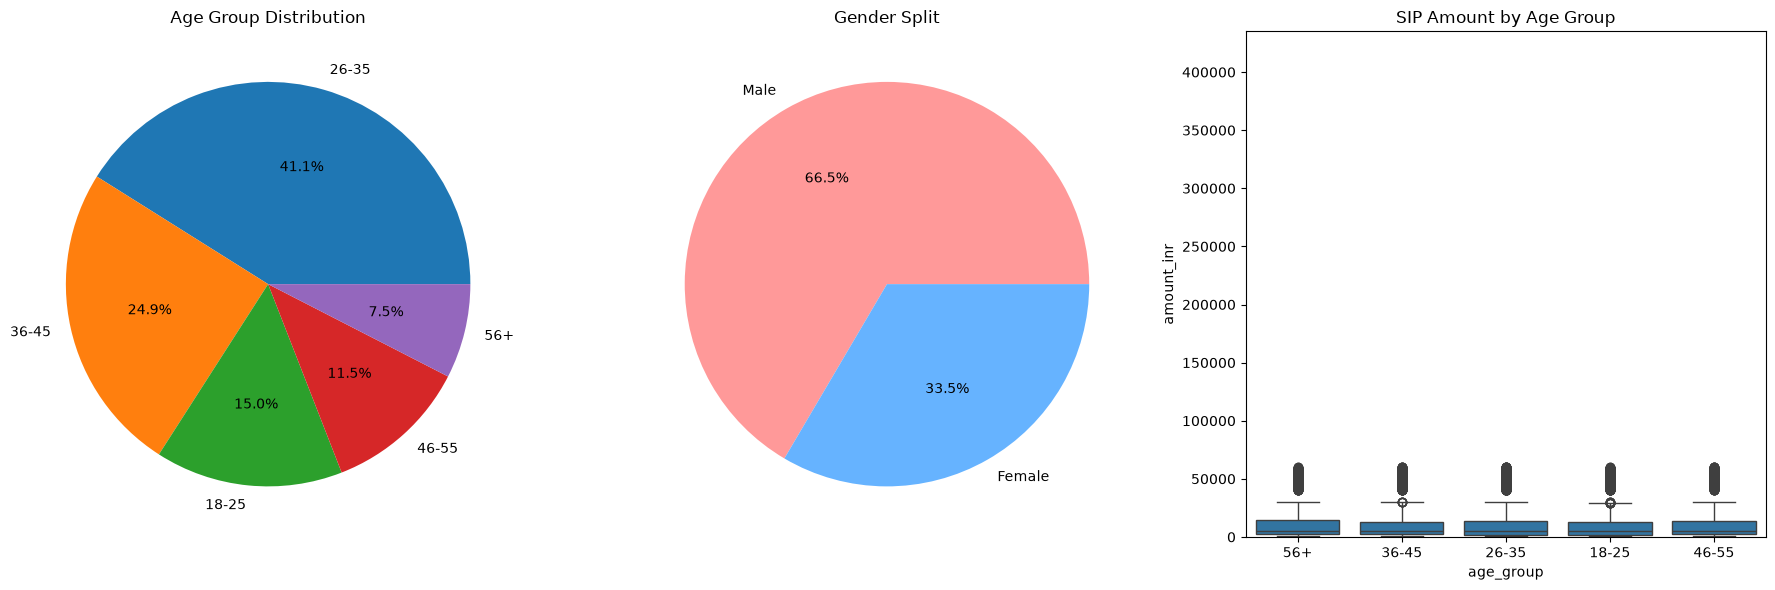

In [6]:

# 5. Investor demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age group pie
age_counts = df_tx['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%')
axes[0].set_title('Age Group Distribution')

# Gender split
gender_counts = df_tx['gender'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[1].set_title('Gender Split')

# SIP amount box plot by age group
sns.boxplot(data=df_tx[df_tx['transaction_type']=='Sip'], x='age_group', y='amount_inr', ax=axes[2])
axes[2].set_title('SIP Amount by Age Group')
axes[2].set_ylim(0, df_tx['amount_inr'].quantile(0.95)) # limit outliers for visibility

plt.tight_layout()
plt.savefig('../reports/charts/investor_demographics.png')
plt.show()


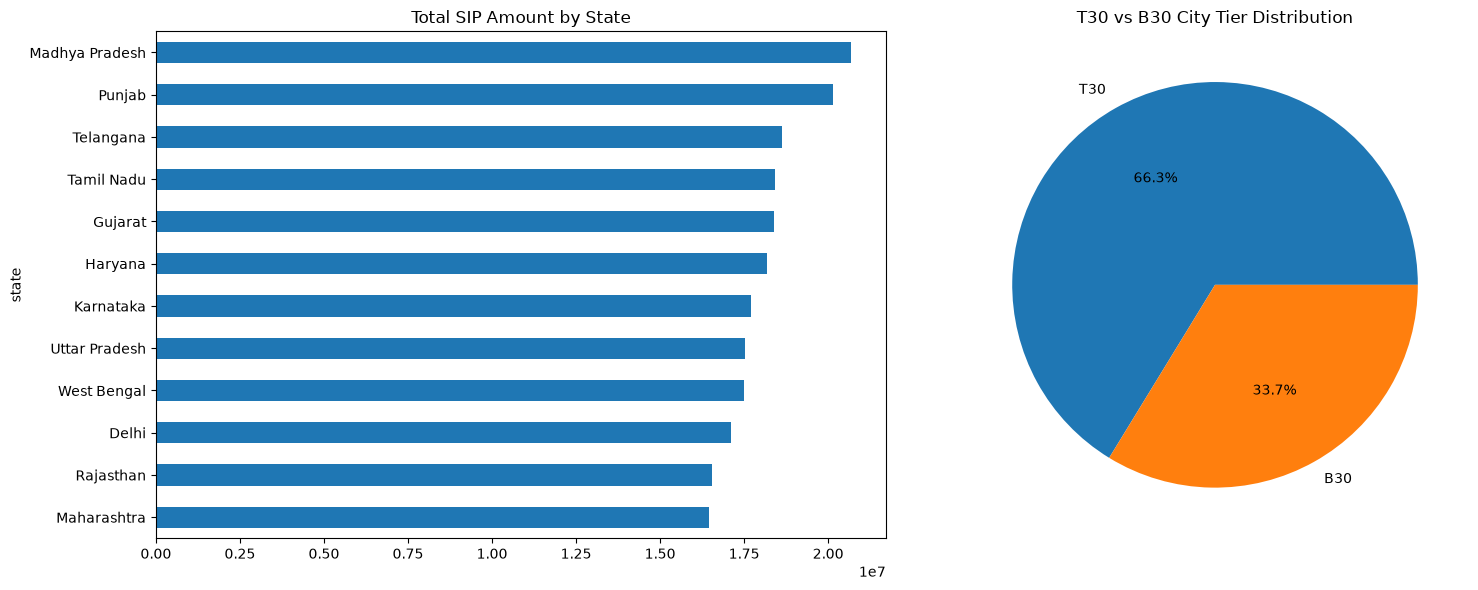

In [7]:

# 6. Geographic distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SIP amount by state
state_sip = df_tx[df_tx['transaction_type']=='Sip'].groupby('state')['amount_inr'].sum().sort_values()
state_sip.plot(kind='barh', ax=axes[0])
axes[0].set_title('Total SIP Amount by State')

# T30 vs B30 pie
tier_counts = df_tx['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%')
axes[1].set_title('T30 vs B30 City Tier Distribution')

plt.tight_layout()
plt.savefig('../reports/charts/geographic_distribution.png')
plt.show()


In [8]:

# 7. Folio count growth
fig = px.line(df_folio, x='month', y='total_folios_crore', title='Mutual Fund Folio Count Growth (2022-2025)')
fig.add_annotation(x='2022-01', y=13.26, text='13.26 Cr', showarrow=True)
fig.add_annotation(x='2025-12', y=26.12, text='26.12 Cr', showarrow=True)
fig.write_image('../reports/charts/folio_growth.png', engine='kaleido', width=1000, height=600)
fig.show()


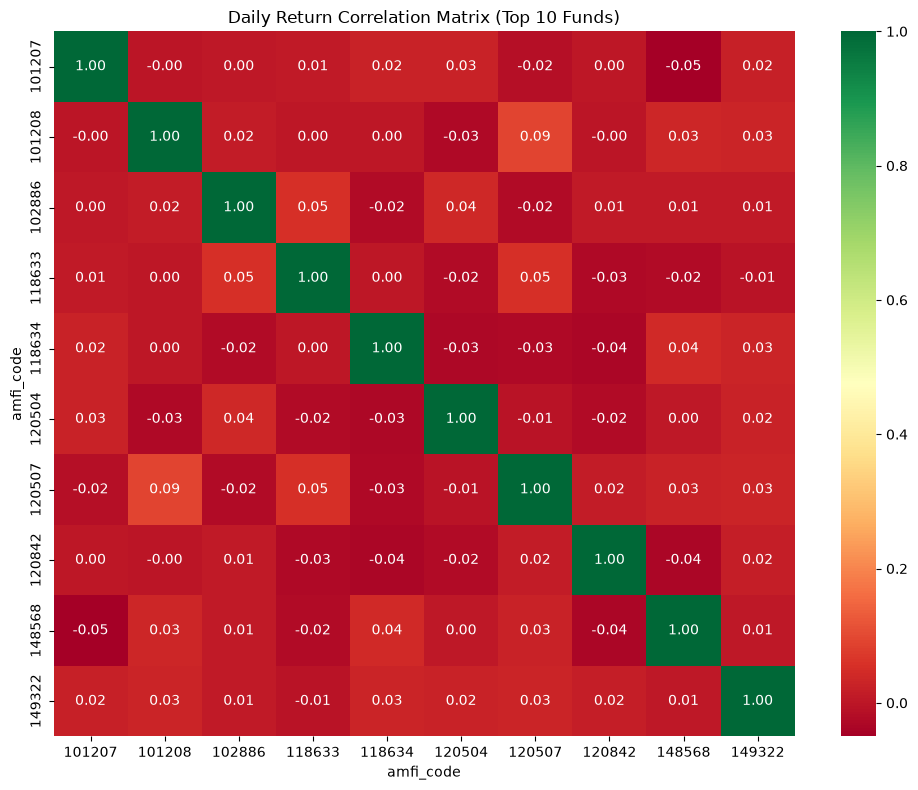

In [9]:

# 8. NAV return correlation matrix
# Select 10 funds (top 10 by AUM)
top_10_funds = df_perf.nlargest(10, 'aum_crore')['amfi_code'].tolist()
df_nav_10 = df_nav[df_nav['amfi_code'].isin(top_10_funds)].copy()
df_nav_10['daily_return'] = df_nav_10.groupby('amfi_code')['nav'].pct_change()
nav_pivot = df_nav_10.pivot(index='date', columns='amfi_code', values='daily_return').dropna()

corr_matrix = nav_pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Daily Return Correlation Matrix (Top 10 Funds)')
plt.tight_layout()
plt.savefig('../reports/charts/return_correlation.png')
plt.show()


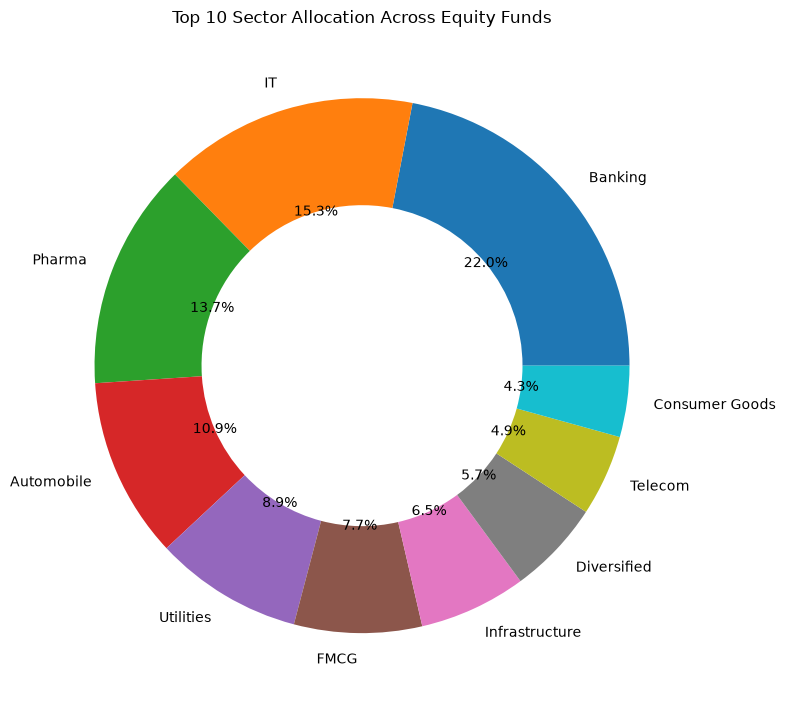

In [10]:

# 9. Sector allocation donut
sector_weights = df_port.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 8))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', wedgeprops=dict(width=0.4))
plt.title('Top 10 Sector Allocation Across Equity Funds')
plt.tight_layout()
plt.savefig('../reports/charts/sector_allocation.png')
plt.show()



# 10 Key EDA Findings

1. **NAV Trends**: The 2023 bull run is clearly visible across most equity schemes, followed by increased volatility in late 2024 (*Reference: NAV Trend Lines*).
2. **AUM Dominance**: SBI Mutual Fund maintains a dominant position, reaching ₹12.5L Cr in AUM by the end of 2025 (*Reference: AUM Growth by AMC*).
3. **SIP Milestones**: Monthly SIP inflows have shown resilient, consistent growth, climaxing at a historic ₹31,002 Cr in December 2025 (*Reference: SIP Inflow Trend*).
4. **Category Preferences**: Large Cap and Mid Cap funds consistently attract the highest net inflows month over month (*Reference: Category Heatmap*).
5. **Investor Age**: The 26-35 and 36-45 age groups form the bulk of the investor base, indicating strong millennial participation (*Reference: Age Group Distribution*).
6. **SIP Affordability**: While older age groups have higher absolute SIP amounts, younger cohorts drive higher volume (*Reference: SIP Amount Box Plot*).
7. **Geographic Concentration**: Maharashtra and Gujarat consistently lead in total transaction volume and SIP amounts (*Reference: Geo Distribution*).
8. **T30 vs B30 Penetration**: T30 cities still dominate the transaction landscape, highlighting an opportunity for B30 market expansion (*Reference: T30 vs B30 Pie*).
9. **Folio Growth**: The industry achieved massive scale, doubling total folios from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025 (*Reference: Folio Count Growth*).
10. **Sector Bias**: Financial Services (Banking) and IT remain the most heavily weighted sectors across the top equity mutual funds (*Reference: Sector Allocation Donut*).
